<a href="https://colab.research.google.com/github/mobarakol/tutorial_notebooks/blob/main/Lab3_2_Multimodal_LLM_for_Surgical_AI_AttentionMap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center><img src="https://drive.google.com/uc?id=1KCWZlI8tS6fyCkbOI3pOUiahyZGjAzug"/ width=400px></center>


**Tutorial Team: Mobarak I. Hoque, Long Bai, and Shi Li**

#Lab 3.2: Multimodal LLM for Surgical AI

This hands-on tutorial is designed to build a multimodal Large Language Model (LLM) for Surgical Visual Question Answering (VQA). It leverages EndoVis-18-VQA, the first and most widely adopted surgical VQA dataset, and enables multimodal vision-language processing by employing LoRA-based fine-tuning on GPT2, the only fully open-source GPT model available.

###Download Dataset and Pretrained Weights

Endovis18-VQA Dataset: https://arxiv.org/pdf/2206.11053

<img src="https://drive.google.com/uc?id=1bm_gfzTFH_u1yd7uRNtJUWrCjTXlZio7" width="500px">

In [ ]:
#Download Dataset
!gdown --id 1FoAEY_u0PTAlrscjEifi2om15A83wL78

# Unzipping the VQA EndoVis18 Dataset
!unzip -q EndoVis-18-VQA.zip

#Download Pretrained Weigths
!gdown --id 1qaejh1nL1wwNmALelgJwbzZtVmjaAbUs

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1FoAEY_u0PTAlrscjEifi2om15A83wL78
From (redirected): https://drive.google.com/uc?id=1FoAEY_u0PTAlrscjEifi2om15A83wL78&confirm=t&uuid=d946e8d7-5741-42dc-9cad-ea0afacbe841
To: /content/EndoVis-18-VQA.zip
100% 2.71G/2.71G [00:42<00:00, 64.3MB/s]
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1qaejh1nL1wwNmALelgJwbzZtVmjaAbUs
From (redirected): https://drive.google.com/uc?id=1qaejh1nL1wwNmALelgJwbzZtVmjaAbUs&confirm=t&uuid=eb772063-8f5f-48e7-a986-1746e96d7440
To: /content/best_m

Install necessary packages

In [ ]:
!pip install -q evaluate bert_score rouge_score

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.2 MB/s eta 0:00:00


### Dataloader

Total files: 1560 | Total question: 10574
Total files: 447 | Total question: 3216
Sample size: Training: 10574 validation: 3216
Question: what organ is being operated?
Answer (label): organ being operated is kidney


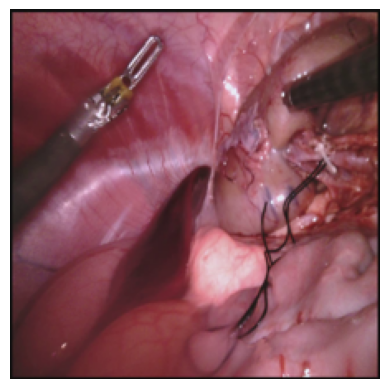

In [ ]:
import os
import glob

from PIL import Image
from torch.utils.data import Dataset
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from pathlib import Path
from torchvision.transforms.functional import InterpolationMode
import matplotlib.pyplot as plt

class EndoVis18VQA(Dataset):
    def __init__(self, seq, folder_head, folder_tail):

        self.transform = transforms.Compose([
            transforms.Resize((224, 224), interpolation=InterpolationMode.BICUBIC),  # input image size
            transforms.ToTensor(),
        ])

        # files, question and answers
        filenames = []
        for curr_seq in seq:
            filenames = filenames + glob.glob(folder_head + str(curr_seq) + folder_tail)
        self.vqas = []
        for file in filenames:
            file_data = open(file, "r")
            lines = [line.strip("\n") for line in file_data if line != "\n"]
            file_data.close()
            for line in lines:
                self.vqas.append([file, line])
        print('Total files: %d | Total question: %.d' % (len(filenames), len(self.vqas)))

    def __len__(self):
        return len(self.vqas)

    def __getitem__(self, idx):
        qa_full_path = Path(self.vqas[idx][0])
        seq_path = qa_full_path.parents[2]
        file_name = self.vqas[idx][0].split('/')[-1]  # / in linux and \\ in windows

        # img
        img_loc = os.path.join(seq_path, 'left_fr', file_name.split('_')[0] + '.png')
        raw_image = Image.open(img_loc).convert('RGB')
        img = self.transform(raw_image)

        # question and answer
        question, answer = self.vqas[idx][1].split('|')

        return img_loc, img, question, answer

# Checking dataset and sample size
train_seq = [2, 3, 4, 6, 7, 9, 10, 11, 12, 14, 15]
val_seq = [1, 5, 16]
folder_head = 'EndoVis-18-VQA/seq_'
folder_tail = '/vqa/Sentence/*.txt'

# dataloader
train_dataset = EndoVis18VQA(train_seq, folder_head, folder_tail)
val_dataset = EndoVis18VQA(val_seq, folder_head, folder_tail)
print('Sample size: Training:', len(train_dataset), 'validation:', len(val_dataset))

img_loc, img, question, answer = train_dataset[0]
plt.axis('OFF')
plt.imshow(img.permute(1,2,0))
print('Question:', question)
print('Answer (label):', answer)

## Model Architecture


This implementation presents a simplified version of the model described in the paper: https://arxiv.org/pdf/2502.14149?<br>
He, R., Khan, D. Z., Mazomenos, E. B., Marcus, H. J., Stoyanov, D., Clarkson, M. J., & Islam, M. (2025). Pitvqa++: Vector matrix-low-rank adaptation for open-ended visual question answering in pituitary surgery. arXiv preprint arXiv:2502.14149.

<img src="https://drive.google.com/uc?id=1Jdi0pj1UnB-3TTU-I5W7kxzSZOhqsGKG" width="800px">

Low Rank Adaptation (LoRA):<br>
<img src="https://learnopencv.com/wp-content/uploads/2024/02/Figure6_lora_animated.gif" width="300px">


In [ ]:
import math
import torch
import torch.nn as nn
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from transformers import ViTModel, BlipTextModel
from peft import get_peft_model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class PitVQAGen(nn.Module):
    def __init__(self, peft_config=None):
        super(PitVQAGen, self).__init__()

        # visual encoder
        model_name = "google/vit-base-patch16-224-in21k"
        self.visual_encoder = ViTModel.from_pretrained(model_name)

        # Freeze all parameters in visual encoder
        for param in self.visual_encoder.parameters():
            param.requires_grad = False

        # tokenizer
        self.tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
        self.tokenizer.pad_token = self.tokenizer.eos_token  # end of string

        # text encoder
        self.text_encoder = BlipTextModel.from_pretrained("Salesforce/blip-vqa-base")

        # modifying blip embedding size to fit with GPT-2
        original_weights = self.text_encoder.embeddings.word_embeddings.weight.data
        new_vocab_size = len(self.tokenizer)
        embedding_dim = self.text_encoder.embeddings.word_embeddings.embedding_dim
        new_embeddings = nn.Embedding(new_vocab_size, embedding_dim)
        original_vocab_size = original_weights.shape[0]
        new_embeddings.weight.data[:original_vocab_size] = original_weights
        self.text_encoder.embeddings.word_embeddings = new_embeddings

        # gpt2 decoder
        gpt = GPT2LMHeadModel.from_pretrained('gpt2')
        self.gpt = get_peft_model(gpt, peft_config)
        self.gpt.print_trainable_parameters()  # Verify trainable MoRA parameters

    def forward(self, image, qa_inputs_ids, qa_att_mask):
        # visual encoder
        image = image.to(device)
        image_embeds = self.visual_encoder(image).last_hidden_state
        image_atts = torch.ones(image_embeds.size()[:-1], dtype=torch.long).to(image.device)

        # multimodal encoder
        text_output = self.text_encoder(input_ids=qa_inputs_ids,
                                        attention_mask=qa_att_mask,
                                        encoder_hidden_states=image_embeds,
                                        encoder_attention_mask=image_atts,
                                        return_dict=True)
        text_embeds = text_output.last_hidden_state

        # text decoder
        gpt_output = self.gpt(inputs_embeds=text_embeds,
                              encoder_attention_mask=qa_att_mask)
        return gpt_output.logits

# Model Training

In [ ]:
import os
import torch
import argparse
import torch.utils.data
import numpy as np
import random

from torch import nn
from torch.utils.data import DataLoader
from transformers import GPT2Tokenizer

import evaluate
from nltk.translate.bleu_score import corpus_bleu
from peft import  TaskType, LoraConfig

import warnings
warnings.filterwarnings('ignore')

def adjust_learning_rate(optimizer, shrink_factor):
    print("\nDECAYING learning rate.")
    for param_group in optimizer.param_groups:
        param_group['lr'] = param_group['lr'] * shrink_factor
    print("The new learning rate is %f\n" % (optimizer.param_groups[0]['lr'],))

def train(args, train_dataloader, model, criterion, optimizer, epoch, tokenizer, device):
    model.train()
    total_loss = []

    for i, (_, images, questions, answers) in enumerate(train_dataloader, 0):
        # prepare prompts
        qa_prompt = [f'Question: {q}\nAnswer: {a}' for q, a in zip(questions, answers)]
        qa_prompt_inputs = tokenizer(qa_prompt, truncation=True, padding="max_length", max_length=int(args.seq_length), return_tensors="pt")

        # get labels
        labels = qa_prompt_inputs['input_ids'].clone()
        labels = labels.to(device)

        # for labels, mask question tokens and padding tokens
        for idx, q in enumerate(questions):
            q_prompt = f"Question: {q}\nAnswer: "
            q_length = len(tokenizer(q_prompt)["input_ids"]) - 1

            labels[idx, :q_length] = -100  # mask question
            eos_mask = (labels[idx] == tokenizer.eos_token_id)  # get all EOS position
            if eos_mask.sum() > 1:  # if more than 1 EOS
                first_eos_pos = eos_mask.nonzero()[0].item()  # get first EOS position
                labels[idx, (first_eos_pos+1):] = -100  # mask paddings, left one EOS

        # get logits and labels
        logits = model(
                image=images.to(device),
                qa_inputs_ids=qa_prompt_inputs['input_ids'].to(device),
                qa_att_mask=qa_prompt_inputs['attention_mask'].to(device)
        )

        # get shifted logits and labels
        shift_logits = logits[:, :-1, :].contiguous()
        shift_labels = labels[:, 1:].contiguous()

        # compute loss
        shift_logits = shift_logits.view(-1, shift_logits.size(-1))
        shift_labels = shift_labels.view(-1)
        loss = criterion(shift_logits, shift_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss.append(loss.item())
        if i%10 == 0:
            print("Training - Epoch: {}/{}, Iteration: {}/{}, AVG Training Loss: {:.6f}".format(epoch, args.epochs, i, len(train_dataloader), np.array(total_loss).mean()))


def validate(args, val_loader, model, criterion, epoch, tokenizer, device):
    total_loss = []
    model.eval()
    with torch.no_grad():
        for i, (_, images, questions, answers) in enumerate(val_loader, 0):
            # prepare prompts
            qa_prompt = [f'Question: {q}\nAnswer: {a}' for q, a in zip(questions, answers)]
            qa_prompt_inputs = tokenizer(qa_prompt, truncation=True, padding="max_length", max_length=int(args.seq_length), return_tensors="pt")

            # get labels
            labels = qa_prompt_inputs['input_ids'].clone()
            labels = labels.to(device)

            # for labels, mask question tokens and padding tokens
            answer_starts = []
            answer_ends = []
            for idx, q in enumerate(questions):
                q_prompt = f"Question: {q}\nAnswer: "
                q_length = len(tokenizer(q_prompt)["input_ids"]) - 1
                answer_starts.append(q_length+1)

                labels[idx, :q_length] = -100  # mask question
                eos_mask = (labels[idx] == tokenizer.eos_token_id)  # get all EOS position
                if eos_mask.sum() > 1:  # if more than 1 EOS
                    first_eos_pos = eos_mask.nonzero()[0].item()  # get first EOS position
                    labels[idx, (first_eos_pos+1):] = -100  # mask paddings, left one EOS
                    answer_ends.append(first_eos_pos)

            # get logits and labels
            logits = model(
                image=images.to(device),
                qa_inputs_ids=qa_prompt_inputs['input_ids'].to(device),
                qa_att_mask=qa_prompt_inputs['attention_mask'].to(device)
            )

            # get shifted logits and labels
            shift_logits = logits[:, :-1, :].contiguous()
            shift_labels = labels[:, 1:].contiguous()

            # compute loss
            shift_logits = shift_logits.view(-1, shift_logits.size(-1))
            shift_labels = shift_labels.view(-1)
            loss = criterion(shift_logits, shift_labels)
            total_loss.append(loss.item())

    return np.array(total_loss).mean()


def seed_everything(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    np.random.seed(seed)
    random.seed(seed)


def get_arg():
    parser = argparse.ArgumentParser(description='VisualQuestionAnswerGeneration')
    # Training parameters
    parser.add_argument('--epochs',         type=int,   default=1,   help='number of epochs to train for')
    parser.add_argument('--batch_size',     type=int,   default=24,   help='batch size')
    parser.add_argument('--workers',        type=int,   default=8,    help='for data-loading')
    parser.add_argument('--random_seed',    type=int,   default=42,   help='random seed')
    parser.add_argument('--seq_length',     type=int,   default=64,   help='sequence length for question and answer')
    parser.add_argument('--dropout', type=float, default=0.1, help='dropout')

    parser.add_argument('--dataset',        default='endo',  help='endo / pit')
    parser.add_argument('--lr',             type=float, default=0.0000002,  help='0.0000001, 0.00000005')
    parser.add_argument('--checkpoint_dir', default='checkpoints/',  help='path to checkpoint')

    args = parser.parse_args([])
    return args


if __name__ == '__main__':

    args = get_arg()
    seed_everything(args.random_seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print(f'Batch size: {args.batch_size}')
    print(f'Learning rate: {args.lr}')
    print(f'Random seed: {args.random_seed}')
    print(f'Sequence length: {args.seq_length}')

    os.makedirs(args.checkpoint_dir, exist_ok = True)
    start_epoch = 1
    epochs_since_improvement = 0
    best_val_loss = float('inf')

    print(f'Dataset: {args.dataset}')
    train_dataloader = None
    val_dataloader = None

    # data location
    # train_seq = [2, 3, 4, 6, 7, 9, 10, 11, 12, 14, 15] #Original Train Set
    # val_seq = [1, 5, 16] #Original Validation Set
    train_seq = [2] #Mini sample for  SDS Summer School 2025
    val_seq = [1]
    folder_head = 'EndoVis-18-VQA/seq_'
    folder_tail = '/vqa/Sentence/*.txt'

    # dataloader
    train_dataset = EndoVis18VQA(train_seq, folder_head, folder_tail)
    train_dataloader = DataLoader(dataset=train_dataset, batch_size=args.batch_size,
                                shuffle=True, num_workers=args.workers)
    val_dataset = EndoVis18VQA(val_seq, folder_head, folder_tail)
    val_dataloader = DataLoader(dataset=val_dataset, batch_size=args.batch_size,
                                shuffle=False, num_workers=args.workers)

    print('Sample size: Training:', len(train_dataset), 'validation:', len(val_dataset))

    # init tokenizer and model
    tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
    tokenizer.pad_token = tokenizer.eos_token

    lora_config = LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=8,
        lora_alpha=16,
        lora_dropout=0.1,
        target_modules=["c_attn", "c_proj"]
    )

    model = PitVQAGen(peft_config=lora_config)
    model = model.to(device)

    pytorch_total_params = sum(p.numel() for p in model.parameters())
    print('model params: ', pytorch_total_params)

    # init optimizer and criterion
    optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)
    criterion = nn.CrossEntropyLoss(ignore_index=-100).to(device)

    # train and validation
    print('Start training.')
    for epoch in range(start_epoch, args.epochs+1):
        if epochs_since_improvement > 0 and epochs_since_improvement % 5 == 0:
            adjust_learning_rate(optimizer, 0.8)

        # train
        train(args, train_dataloader=train_dataloader, model=model, criterion=criterion, optimizer=optimizer,
              epoch=epoch, tokenizer=tokenizer, device=device)
        # validation
        val_loss = validate(args, val_loader=val_dataloader, model=model, criterion=criterion,
                            epoch=epoch, tokenizer=tokenizer, device=device)

        if val_loss < best_val_loss:  # save model with better validation loss
            epochs_since_improvement = 0
            best_val_loss = val_loss
            save_dir = f'{args.checkpoint_dir}/best_model_mini.pth'
            torch.save(model.state_dict(), save_dir)
            model.tokenizer.save_pretrained(args.checkpoint_dir)
            print('Best validation loss, model saved.')
        else:
            epochs_since_improvement += 1
            print("\nEpochs since last improvement: %d\n" % (epochs_since_improvement,))
    print('End training.')

Batch size: 24
Learning rate: 2e-07
Random seed: 42
Sequence length: 64
Dataset: endo
Total files: 137 | Total question: 1046
Total files: 149 | Total question: 1164
Sample size: Training: 1046 validation: 1164


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.54G [00:00<?, ?B/s]

Some weights of BlipTextModel were not initialized from the model checkpoint at Salesforce/blip-vqa-base and are newly initialized: ['embeddings.LayerNorm.bias', 'embeddings.LayerNorm.weight', 'embeddings.position_embeddings.weight', 'embeddings.word_embeddings.weight', 'encoder.layer.0.attention.output.LayerNorm.bias', 'encoder.layer.0.attention.output.LayerNorm.weight', 'encoder.layer.0.attention.output.dense.bias', 'encoder.layer.0.attention.output.dense.weight', 'encoder.layer.0.attention.self.key.bias', 'encoder.layer.0.attention.self.key.weight', 'encoder.layer.0.attention.self.query.bias', 'encoder.layer.0.attention.self.query.weight', 'encoder.layer.0.attention.self.value.bias', 'encoder.layer.0.attention.self.value.weight', 'encoder.layer.0.crossattention.output.LayerNorm.bias', 'encoder.layer.0.crossattention.output.LayerNorm.weight', 'encoder.layer.0.crossattention.output.dense.bias', 'encoder.layer.0.crossattention.output.dense.weight', 'encoder.layer.0.crossattention.self.

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

trainable params: 811,008 || all params: 125,250,816 || trainable%: 0.6475
model params:  364644096
Start training.
Training - Epoch: 1/1, Iteration: 0/44, AVG Training Loss: 9.434325
Training - Epoch: 1/1, Iteration: 10/44, AVG Training Loss: 9.318302
Training - Epoch: 1/1, Iteration: 20/44, AVG Training Loss: 9.243941
Training - Epoch: 1/1, Iteration: 30/44, AVG Training Loss: 9.173917
Training - Epoch: 1/1, Iteration: 40/44, AVG Training Loss: 9.086332
Best validation loss, model saved.
End training.


#Inference: Few Samples



Some weights of BlipTextModel were not initialized from the model checkpoint at Salesforce/blip-vqa-base and are newly initialized: ['embeddings.LayerNorm.bias', 'embeddings.LayerNorm.weight', 'embeddings.position_embeddings.weight', 'embeddings.word_embeddings.weight', 'encoder.layer.0.attention.output.LayerNorm.bias', 'encoder.layer.0.attention.output.LayerNorm.weight', 'encoder.layer.0.attention.output.dense.bias', 'encoder.layer.0.attention.output.dense.weight', 'encoder.layer.0.attention.self.key.bias', 'encoder.layer.0.attention.self.key.weight', 'encoder.layer.0.attention.self.query.bias', 'encoder.layer.0.attention.self.query.weight', 'encoder.layer.0.attention.self.value.bias', 'encoder.layer.0.attention.self.value.weight', 'encoder.layer.0.crossattention.output.LayerNorm.bias', 'encoder.layer.0.crossattention.output.LayerNorm.weight', 'encoder.layer.0.crossattention.output.dense.bias', 'encoder.layer.0.crossattention.output.dense.weight', 'encoder.layer.0.crossattention.self.

trainable params: 811,008 || all params: 125,250,816 || trainable%: 0.6475
Total files: 149 | Total question: 1164


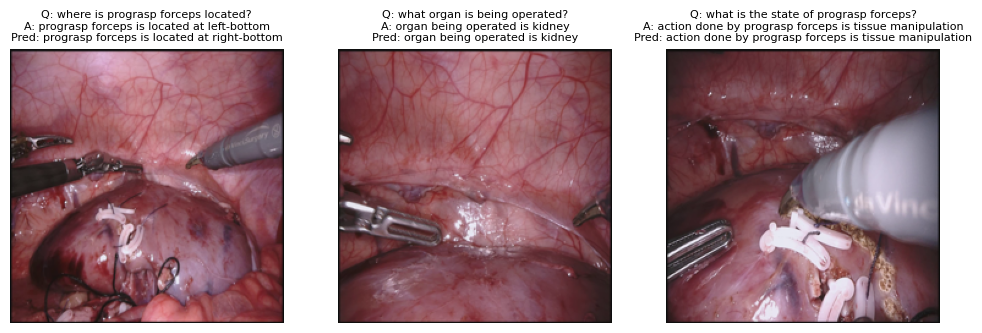

In [ ]:
from tqdm import tqdm
import evaluate

import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from transformers import ViTModel, BlipTextModel
from peft import get_peft_model
from peft import  TaskType, LoraConfig
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

def greedy_search_single(image, question, model, tokenizer, max_length, device):
    model.eval()
    with torch.no_grad():
        # Prepare prompt and tokenize
        prompt_text = f"Question: {question}\nAnswer:"
        inputs = tokenizer(prompt_text, return_tensors="pt", add_special_tokens=False)
        input_ids = inputs['input_ids'].to(device)
        attention_mask = inputs['attention_mask'].to(device)

        # Pad to max_length
        padded_input_ids = torch.zeros((1, max_length), dtype=torch.long, device=device)
        padded_attention_mask = torch.zeros((1, max_length), dtype=torch.long, device=device)
        seq_len = input_ids.size(1)
        padded_input_ids[:, :seq_len] = input_ids
        padded_attention_mask[:, :seq_len] = attention_mask

        valid_length = seq_len
        generated_ids = []

        image = image.unsqueeze(0).to(device)  # Add batch dim

        for _ in range(max_length - seq_len):
            logits = model(
                image=image,
                qa_inputs_ids=padded_input_ids[:, :valid_length],
                qa_att_mask=padded_attention_mask[:, :valid_length]
            )

            last_logits = logits[0, valid_length - 1]  # shape: [vocab_size]
            next_token_id = torch.argmax(F.softmax(last_logits, dim=-1), dim=-1)

            if next_token_id.item() == tokenizer.eos_token_id:
                break

            padded_input_ids[0, valid_length] = next_token_id
            padded_attention_mask[0, valid_length] = 1
            valid_length += 1
            generated_ids.append(next_token_id.item())

        # Decode generated tokens
        answer = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
        return answer


def inference_few_samples(sample_indices = [4, 5, 7]):
    lora_config = LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=8,
        lora_alpha=16,
        lora_dropout=0.1,
        target_modules=["c_attn", "c_proj"]
    )

    model = PitVQAGen(peft_config=lora_config)
    # save_dir = f'{args.checkpoint_dir}/best_model_sds.pth'
    save_dir = f'best_model_sds.pth'
    model.load_state_dict(torch.load(save_dir, map_location=device))
    model.to(device)
    model.eval()

    tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
    tokenizer.pad_token = tokenizer.eos_token

    val_seq = [1]
    folder_head = 'EndoVis-18-VQA/seq_'
    folder_tail = '/vqa/Sentence/*.txt'
    val_dataset = EndoVis18VQA(val_seq, folder_head, folder_tail)

    # Create subplots
    fig, axes = plt.subplots(1, len(sample_indices), figsize=(12, 5))  # 1 row, 3 columns
    for ax, idx in zip(axes, sample_indices):
        _, img, question, answer_gt = val_dataset[idx]

        # Run inference
        pred_answer = greedy_search_single(img, question, model, tokenizer, max_length=32, device=device)
        img = img.permute(1, 2, 0)  # Convert from [C, H, W] to [H, W, C] for imshow
        ax.imshow(img)
        ax.set_title(f'Q: {question}\nA: {answer_gt}\nPred: {pred_answer}', fontsize=8)
        ax.axis('off')


inference_few_samples(sample_indices = [46, 56, 66])


#Attention Maps from BLIP transformer

Some weights of BlipTextModel were not initialized from the model checkpoint at Salesforce/blip-vqa-base and are newly initialized: ['embeddings.LayerNorm.bias', 'embeddings.LayerNorm.weight', 'embeddings.position_embeddings.weight', 'embeddings.word_embeddings.weight', 'encoder.layer.0.attention.output.LayerNorm.bias', 'encoder.layer.0.attention.output.LayerNorm.weight', 'encoder.layer.0.attention.output.dense.bias', 'encoder.layer.0.attention.output.dense.weight', 'encoder.layer.0.attention.self.key.bias', 'encoder.layer.0.attention.self.key.weight', 'encoder.layer.0.attention.self.query.bias', 'encoder.layer.0.attention.self.query.weight', 'encoder.layer.0.attention.self.value.bias', 'encoder.layer.0.attention.self.value.weight', 'encoder.layer.0.crossattention.output.LayerNorm.bias', 'encoder.layer.0.crossattention.output.LayerNorm.weight', 'encoder.layer.0.crossattention.output.dense.bias', 'encoder.layer.0.crossattention.output.dense.weight', 'encoder.layer.0.crossattention.self.

trainable params: 811,008 || all params: 125,250,816 || trainable%: 0.6475
Total files: 149 | Total question: 1164
cross_attns
cross_attns
cross_attns
cross_attns
cross_attns
cross_attns
cross_attns


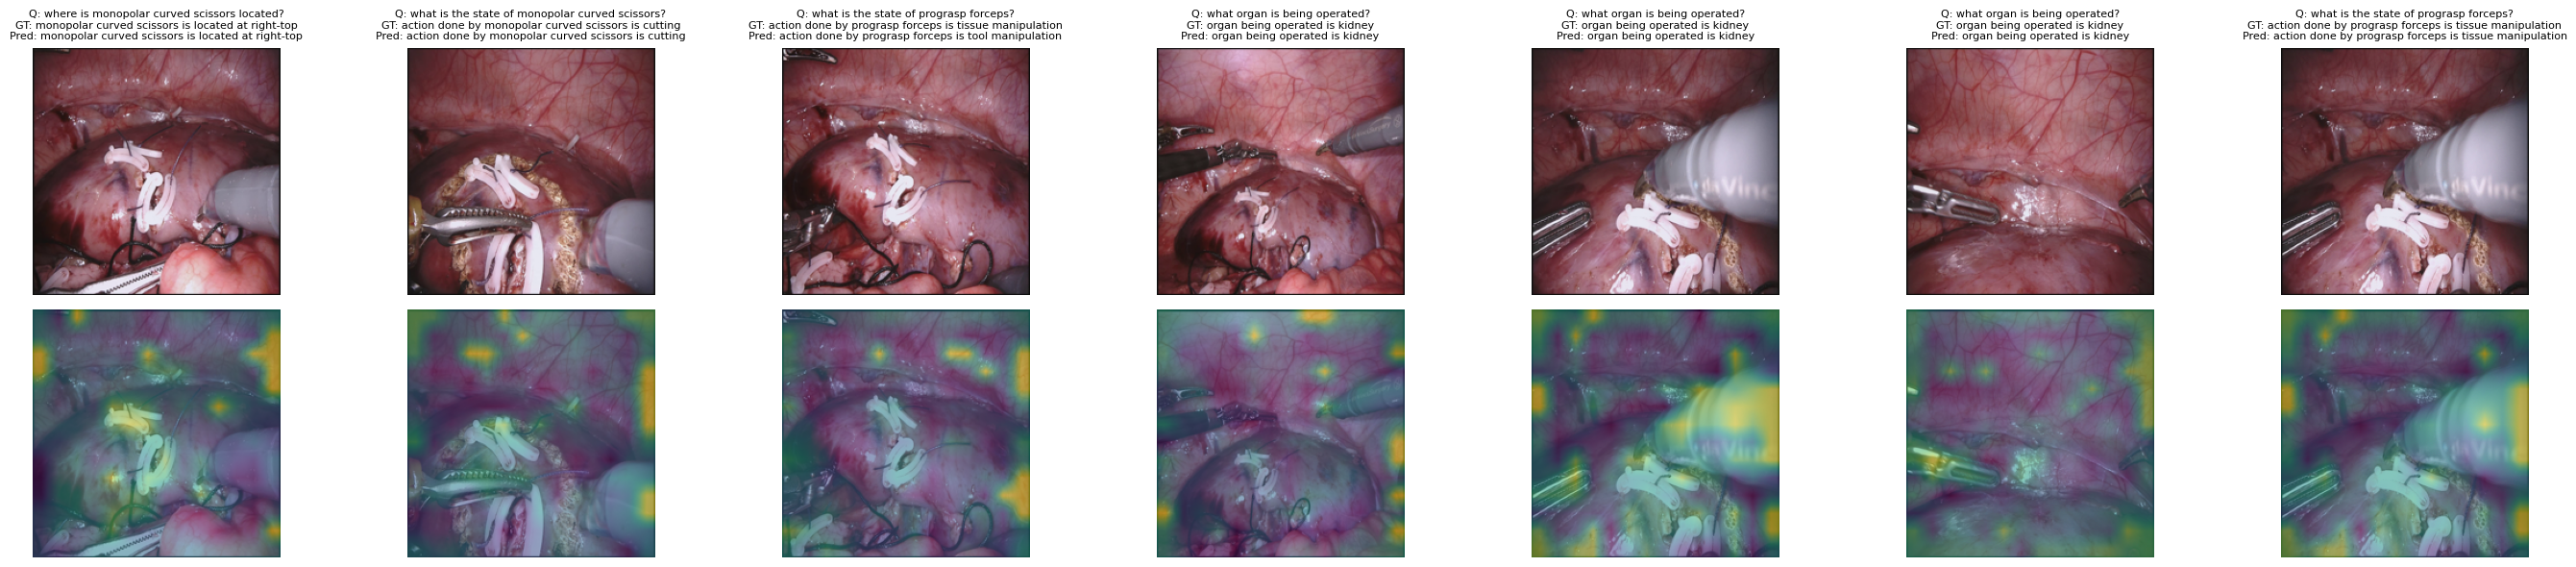

In [ ]:
class PitVQAGen_AM(nn.Module):
    def __init__(self, peft_config=None):
        super(PitVQAGen_AM, self).__init__()

        model_name = "google/vit-base-patch16-224-in21k"
        self.visual_encoder = ViTModel.from_pretrained(
            model_name,
            output_attentions=True,
            return_dict=True
        )

        for param in self.visual_encoder.parameters():
            param.requires_grad = False

        self.tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
        self.tokenizer.pad_token = self.tokenizer.eos_token

        self.text_encoder = BlipTextModel.from_pretrained(
            "Salesforce/blip-vqa-base",
            output_attentions=True,
            return_dict=True
        )

        original_weights = self.text_encoder.embeddings.word_embeddings.weight.data
        new_vocab_size = len(self.tokenizer)
        embedding_dim = self.text_encoder.embeddings.word_embeddings.embedding_dim
        new_embeddings = nn.Embedding(new_vocab_size, embedding_dim)
        original_vocab_size = original_weights.shape[0]
        new_embeddings.weight.data[:original_vocab_size] = original_weights
        self.text_encoder.embeddings.word_embeddings = new_embeddings

        gpt = GPT2LMHeadModel.from_pretrained(
            'gpt2',
            output_attentions=True,
            return_dict=True
        )
        self.gpt = get_peft_model(gpt, peft_config)
        self.gpt.print_trainable_parameters()

    def forward(self, image, qa_inputs_ids, qa_att_mask, output_attentions=False):
        image = image.to(device)

        vit_output = self.visual_encoder(
            image,
            output_attentions=output_attentions,
            return_dict=True
        )
        image_embeds = vit_output.last_hidden_state
        vit_attns = vit_output.attentions if output_attentions else None

        image_atts = torch.ones(
            image_embeds.size()[:-1],
            dtype=torch.long,
            device=image.device
        )

        text_output = self.text_encoder(
            input_ids=qa_inputs_ids,
            attention_mask=qa_att_mask,
            encoder_hidden_states=image_embeds,
            encoder_attention_mask=image_atts,
            output_attentions=output_attentions,
            return_dict=True
        )
        text_embeds = text_output.last_hidden_state

        txt_self_attns = text_output.attentions if output_attentions else None

        cross_attns = None
        if output_attentions:
            cross_attns = getattr(text_output, "encoder_attentions", None)
            if cross_attns is None:
                cross_attns = getattr(text_output, "cross_attentions", None)

        gpt_output = self.gpt(
            inputs_embeds=text_embeds,
            attention_mask=qa_att_mask,
            output_attentions=output_attentions,
            return_dict=True
        )
        logits = gpt_output.logits
        gpt_attns = gpt_output.attentions if output_attentions else None

        if not output_attentions:
            return logits

        return {
            "logits": logits,
            "vit_attns": vit_attns,
            "txt_self_attns": txt_self_attns,
            "cross_attns": cross_attns,
            "gpt_attns": gpt_attns,
            "image_embeds": image_embeds,
        }



# def cross_attention_to_patch_heatmap(cross_attns, eps=1e-8):
#     """
#     cross_attns: tuple of length L
#       each [B, heads, T, S]  T text tokens, S image tokens
#     returns [B, H, W] heatmap averaged over layers, heads, and text tokens
#     """

#     attn = torch.stack(cross_attns, dim=0)       # [L, B, heads, T, S]
#     print('cross_attns shape:', attn.shape)
#     attn = attn.mean(dim=(0, 2))                # [B, T, S]
#     print('cross_attns mean shape:', attn.shape)

#     # cross_attns shape: torch.Size([12, 1, 12, 23, 197])
#     # cross_attns mean shape: torch.Size([1, 23, 197])

#     attn_text_mean = attn.mean(dim=1)           # [B, S]

#     patch_attn = attn_text_mean[:, 1:]          # drop cls image token

#     num_patches = patch_attn.size(-1)
#     grid_size = int(num_patches ** 0.5)

#     patch_attn = patch_attn.view(-1, grid_size, grid_size)  # [B, H, W]

#     patch_attn = patch_attn - patch_attn.amin(dim=(1, 2), keepdim=True)
#     patch_attn = patch_attn / (patch_attn.amax(dim=(1, 2), keepdim=True) + eps)

#     return patch_attn

def cross_attention_to_patch_heatmap(cross_attns, eps=1e-8):
    """
    cross_attns: tuple (L) each [B, heads, T, S]
    returns: [B, H_grid, W_grid]
    """

    # stack: [L, B, H, T, S] [12, 1, 12, 23, 197]
    attn = torch.stack(cross_attns, dim=0)

    # 1️⃣ average over layers → [B, H, T, S]
    # attn = attn.mean(dim=0) # all trnasformer blocks
    # attn = attn[6:].mean(dim=0) # last few trnasformer blocks
    attn = attn [-1] # only last trnasformer blocks

    # 2️⃣ average over heads → [B, T, S]
    attn = attn.mean(dim=1)

    # 3️⃣ average over text tokens → [B, S]
    attn = attn.mean(dim=1)

    # drop CLS at position 0 → [B, S-1]
    # print('bef CLS', attn.shape)
    attn = attn[:, 1:]
    # print('aft CLS', attn.shape)

    # reshape → [B, grid, grid]
    num_patches = attn.size(-1)
    grid = int(num_patches**0.5)
    attn = attn.view(-1, grid, grid)

    # normalize 0..1
    attn = attn - attn.amin(dim=(1, 2), keepdim=True)
    attn = attn / (attn.amax(dim=(1, 2), keepdim=True) + eps)

    return attn


# import math

# def cross_attention_to_patch_heatmap(cross_attns, token_index=-1, eps=1e-8):

#     # stack layers: [L, B, H, T, S]
#     attn = torch.stack(cross_attns, dim=0)

#     # average over layers → [B, H, T, S]
#     attn = attn.mean(dim=0)

#     # average over heads → [B, T, S]
#     attn = attn.mean(dim=1)

#     B, T, S = attn.shape

#     # handle negative index (for example token_index = -1)
#     if token_index < 0:
#         token_index = T + token_index
#     token_index = max(0, min(T - 1, token_index))

#     # select the chosen text token → [B, S]
#     attn = attn[:, token_index]

#     # decide whether first image token is CLS
#     use_cls = False
#     if S > 1 and int(math.sqrt(S - 1)) ** 2 == (S - 1):
#         use_cls = True

#     if use_cls:
#         patch_scores = attn[:, 1:]    # drop CLS
#     else:
#         patch_scores = attn           # use all tokens as patches

#     num_patches = patch_scores.size(-1)
#     grid = int(math.sqrt(num_patches))
#     assert grid * grid == num_patches, f"num_patches {num_patches} is not a square"

#     # reshape → [B, grid, grid]
#     attn = patch_scores.view(B, grid, grid)

#     # normalize to [0, 1]
#     attn = attn - attn.amin(dim=(1, 2), keepdim=True)
#     attn = attn / (attn.amax(dim=(1, 2), keepdim=True) + eps)

#     return attn



def greedy_search_single(image, question, model, tokenizer, max_length, device):
    model.eval()
    with torch.no_grad():
        prompt_text = f"Question: {question}\nAnswer:"
        inputs = tokenizer(prompt_text, return_tensors="pt", add_special_tokens=False)
        input_ids = inputs['input_ids'].to(device)
        attention_mask = inputs['attention_mask'].to(device)

        padded_input_ids = torch.zeros((1, max_length), dtype=torch.long, device=device)
        padded_attention_mask = torch.zeros((1, max_length), dtype=torch.long, device=device)
        seq_len = input_ids.size(1)
        padded_input_ids[:, :seq_len] = input_ids
        padded_attention_mask[:, :seq_len] = attention_mask

        valid_length = seq_len
        generated_ids = []

        image = image.unsqueeze(0).to(device)

        for _ in range(max_length - seq_len):
            logits = model(
                image=image,
                qa_inputs_ids=padded_input_ids[:, :valid_length],
                qa_att_mask=padded_attention_mask[:, :valid_length],
                # default output_attentions=False, so logits tensor
            )

            last_logits = logits[0, valid_length - 1]
            next_token_id = torch.argmax(F.softmax(last_logits, dim=-1), dim=-1)

            if next_token_id.item() == tokenizer.eos_token_id:
                break

            padded_input_ids[0, valid_length] = next_token_id
            padded_attention_mask[0, valid_length] = 1
            valid_length += 1
            generated_ids.append(next_token_id.item())

        answer = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

        # slice to actual used length for later attention computation
        final_input_ids = padded_input_ids[:, :valid_length]
        final_att_mask = padded_attention_mask[:, :valid_length]

        return answer, final_input_ids, final_att_mask

def inference_few_samples(sample_indices = [4, 81]):
    lora_config = LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=8,
        lora_alpha=16,
        lora_dropout=0.1,
        target_modules=["c_attn", "c_proj"]
    )

    model = PitVQAGen_AM(peft_config=lora_config)
    save_dir = 'best_model_sds.pth'
    model.load_state_dict(torch.load(save_dir, map_location=device))
    model.to(device)
    model.eval()

    tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
    tokenizer.pad_token = tokenizer.eos_token

    val_seq = [1]
    folder_head = 'EndoVis-18-VQA/seq_'
    folder_tail = '/vqa/Sentence/*.txt'
    val_dataset = EndoVis18VQA(val_seq, folder_head, folder_tail)

    fig, axes = plt.subplots(
        2,
        len(sample_indices),
        figsize=(4 * len(sample_indices), 6),
        squeeze=False
    )

    for col, idx in enumerate(sample_indices):
        _, img, question, answer_gt = val_dataset[idx]   # img [C,H,W], tensor

        # generate prediction
        pred_answer, final_input_ids, final_att_mask = greedy_search_single(
            img, question, model, tokenizer, max_length=32, device=device
        )

        # row 1: raw image
        ax_img = axes[0, col]
        img_np = img.permute(1, 2, 0).cpu().numpy()
        ax_img.imshow(img_np)
        ax_img.set_title(
            f"Q: {question}\nGT: {answer_gt}\nPred: {pred_answer}",
            fontsize=8
        )
        ax_img.axis('off')

        # row 2: attention overlay
        ax_attn = axes[1, col]

        with torch.no_grad():
            image_batch = img.unsqueeze(0).to(device)
            outputs = model(
                image=image_batch,
                qa_inputs_ids=final_input_ids.to(device),
                qa_att_mask=final_att_mask.to(device),
                output_attentions=True
            )

            if outputs["cross_attns"] is not None:
                print("cross_attns")
                heatmaps = cross_attention_to_patch_heatmap(outputs["cross_attns"])
            # else:
            #     heatmaps = vit_cls_attention_to_heatmap(outputs["vit_attns"])

            heatmap = heatmaps[0]                  # [H_p, W_p]

            # upsample to image size
            hmap = heatmap.unsqueeze(0).unsqueeze(0)   # [1,1,h,w]
            h_up = F.interpolate(
                hmap,
                size=img.shape[1:],  # (H,W)
                mode="bilinear",
                align_corners=False
            )[0, 0].cpu().numpy()

        ax_attn.imshow(img_np)
        ax_attn.imshow(h_up, alpha=0.5)
        ax_attn.axis('off')

        if col == 0:
            ax_img.set_ylabel("Image", fontsize=10)
            ax_attn.set_ylabel("Attention", fontsize=10)

    plt.tight_layout()
    plt.show()


# run
inference_few_samples(sample_indices=[15, 20, 35, 40, 64, 56, 66])


#Attention Maps from Vision transformer

Some weights of BlipTextModel were not initialized from the model checkpoint at Salesforce/blip-vqa-base and are newly initialized: ['embeddings.LayerNorm.bias', 'embeddings.LayerNorm.weight', 'embeddings.position_embeddings.weight', 'embeddings.word_embeddings.weight', 'encoder.layer.0.attention.output.LayerNorm.bias', 'encoder.layer.0.attention.output.LayerNorm.weight', 'encoder.layer.0.attention.output.dense.bias', 'encoder.layer.0.attention.output.dense.weight', 'encoder.layer.0.attention.self.key.bias', 'encoder.layer.0.attention.self.key.weight', 'encoder.layer.0.attention.self.query.bias', 'encoder.layer.0.attention.self.query.weight', 'encoder.layer.0.attention.self.value.bias', 'encoder.layer.0.attention.self.value.weight', 'encoder.layer.0.crossattention.output.LayerNorm.bias', 'encoder.layer.0.crossattention.output.LayerNorm.weight', 'encoder.layer.0.crossattention.output.dense.bias', 'encoder.layer.0.crossattention.output.dense.weight', 'encoder.layer.0.crossattention.self.

trainable params: 811,008 || all params: 125,250,816 || trainable%: 0.6475
Total files: 149 | Total question: 1164


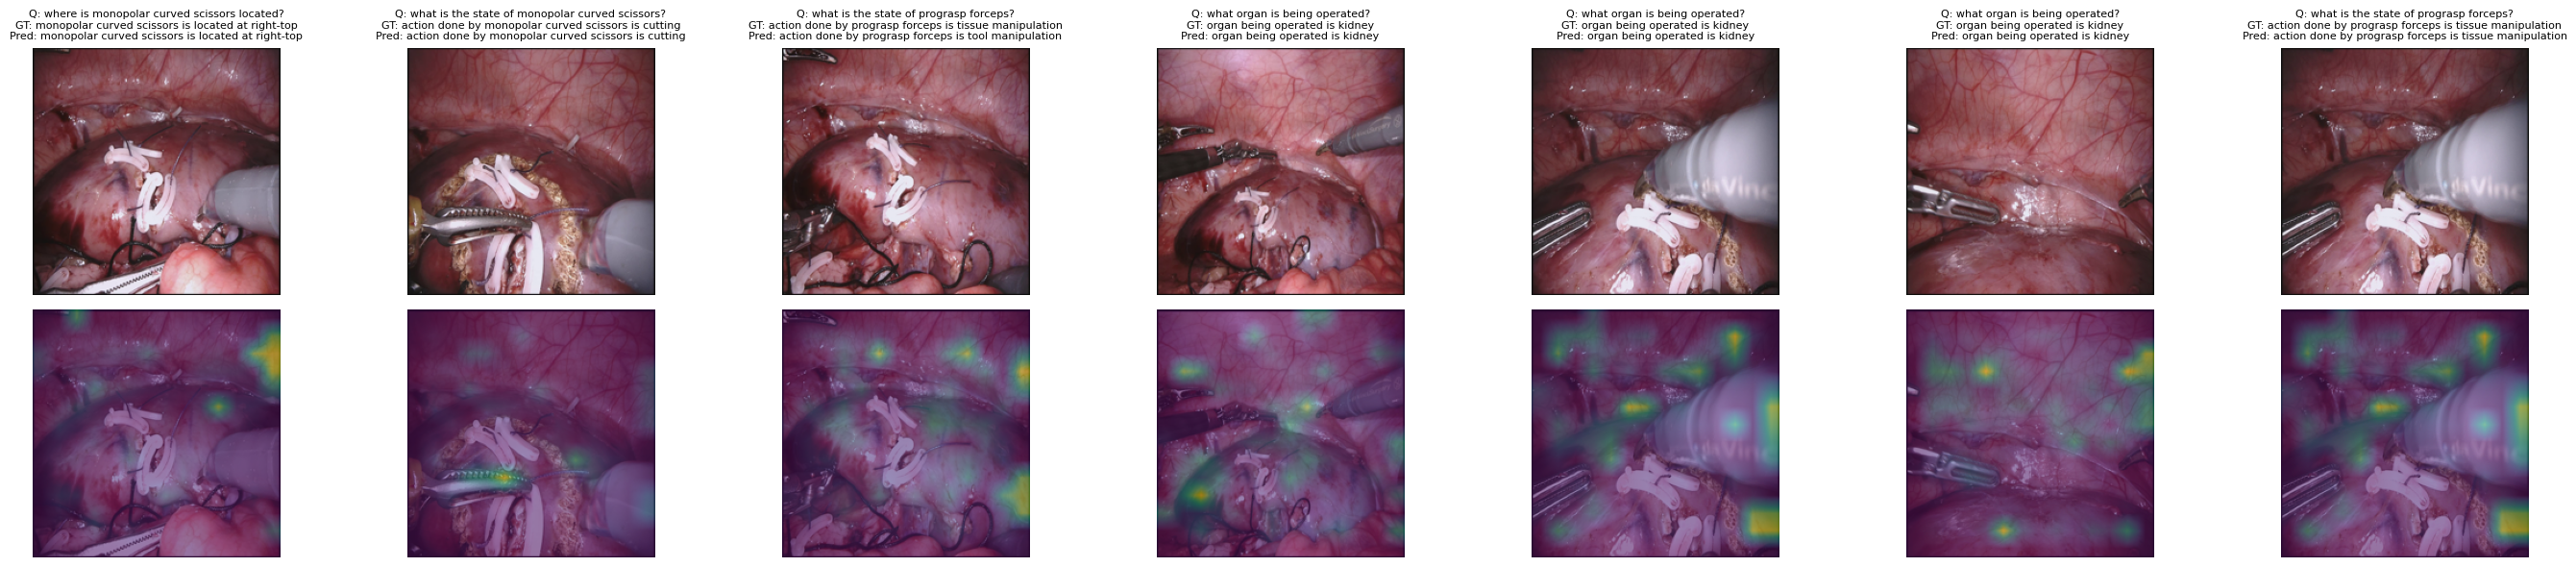

In [ ]:
class PitVQAGen_AM(nn.Module):
    def __init__(self, peft_config=None):
        super(PitVQAGen_AM, self).__init__()

        model_name = "google/vit-base-patch16-224-in21k"
        self.visual_encoder = ViTModel.from_pretrained(
            model_name,
            output_attentions=True,
            return_dict=True
        )

        for param in self.visual_encoder.parameters():
            param.requires_grad = False

        self.tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
        self.tokenizer.pad_token = self.tokenizer.eos_token

        self.text_encoder = BlipTextModel.from_pretrained(
            "Salesforce/blip-vqa-base",
            output_attentions=True,
            return_dict=True
        )

        original_weights = self.text_encoder.embeddings.word_embeddings.weight.data
        new_vocab_size = len(self.tokenizer)
        embedding_dim = self.text_encoder.embeddings.word_embeddings.embedding_dim
        new_embeddings = nn.Embedding(new_vocab_size, embedding_dim)
        original_vocab_size = original_weights.shape[0]
        new_embeddings.weight.data[:original_vocab_size] = original_weights
        self.text_encoder.embeddings.word_embeddings = new_embeddings

        gpt = GPT2LMHeadModel.from_pretrained(
            'gpt2',
            output_attentions=True,
            return_dict=True
        )
        self.gpt = get_peft_model(gpt, peft_config)
        self.gpt.print_trainable_parameters()

    def forward(self, image, qa_inputs_ids, qa_att_mask, output_attentions=False):
        image = image.to(device)

        vit_output = self.visual_encoder(
            image,
            output_attentions=output_attentions,
            return_dict=True
        )
        image_embeds = vit_output.last_hidden_state
        vit_attns = vit_output.attentions if output_attentions else None

        image_atts = torch.ones(
            image_embeds.size()[:-1],
            dtype=torch.long,
            device=image.device
        )

        text_output = self.text_encoder(
            input_ids=qa_inputs_ids,
            attention_mask=qa_att_mask,
            encoder_hidden_states=image_embeds,
            encoder_attention_mask=image_atts,
            output_attentions=output_attentions,
            return_dict=True
        )
        text_embeds = text_output.last_hidden_state

        txt_self_attns = text_output.attentions if output_attentions else None

        cross_attns = None
        if output_attentions:
            cross_attns = getattr(text_output, "encoder_attentions", None)
            if cross_attns is None:
                cross_attns = getattr(text_output, "cross_attentions", None)

        gpt_output = self.gpt(
            inputs_embeds=text_embeds,
            attention_mask=qa_att_mask,
            output_attentions=output_attentions,
            return_dict=True
        )
        logits = gpt_output.logits
        gpt_attns = gpt_output.attentions if output_attentions else None

        if not output_attentions:
            return logits

        return {
            "logits": logits,
            "vit_attns": vit_attns,
            "txt_self_attns": txt_self_attns,
            "cross_attns": cross_attns,
            "gpt_attns": gpt_attns,
            "image_embeds": image_embeds,
        }

# def vit_cls_attention_to_heatmap(vit_attns, eps=1e-8):
#     """
#     vit_attns: tuple of attention tensors across L layers
#       each element has shape [B, heads, N, N]
#       N = 1 + number of image patches (CLS + patches)
#     returns a heatmap shaped [B, H, W] where H=W=(patch_grid_size)
#     """
#     last_layer_attn = vit_attns[-1]                    # get attention from the last ViT layer (strongest signal)

#     B, H, N, _ = last_layer_attn.shape                # unpack batch size, number of heads, number of tokens

#     attn = last_layer_attn.mean(dim=1)                # average across heads → shape [B, N, N]

#     cls_attn = attn[:, 0]                             # take attention originating from class token → [B, N]

#     patch_attn = cls_attn[:, 1:]                      # remove class token itself, keep only patch attention → [B, N-1]

#     num_patches = patch_attn.size(-1)                 # total number of patches = N - 1
#     grid_size = int(num_patches ** 0.5)               # convert to 2D grid length (e.g., 14×14 patches for ViT-B/16)

#     patch_attn = patch_attn.view(B, grid_size, grid_size)  # reshape into spatial grid → [B, H, W]

#     patch_attn = patch_attn - patch_attn.amin(dim=(1, 2), keepdim=True)  # normalize: shift minimum to 0
#     patch_attn = patch_attn / (patch_attn.amax(dim=(1, 2), keepdim=True) + eps)  # normalize: scale so max=1 (avoid div-by-zero)

#     return patch_attn                                  # heatmap ready for visualization


def vit_mean_attention_to_heatmap(vit_attns, eps=1e-8):
    """
    vit_attns: tuple length L, each [B, heads, N, N]
    returns mean attention across all layers and heads, reshaped to [B, H, W]
    """

    # stack layers → shape [L, B, heads, N, N]
    attn = torch.stack(vit_attns, dim=0)

    # average over layers and heads → shape [B, N, N]
    attn = attn.mean(dim=(0, 2))

    # # get attention from the last ViT layer (strongest signal)
    # last_layer_attn = vit_attns[-1]

    # attention coming from CLS token (index 0) → [B, N]
    cls_attn = attn[:, 0]

    # drop CLS entry and keep only patch tokens → [B, N-1]
    patch_attn = cls_attn[:, 1:]

    # infer patch grid resolution (e.g. 14×14 = 196 patches)
    num_patches = patch_attn.size(-1)
    grid_size = int(num_patches ** 0.5)

    # reshape to spatial grid → [B, H, W]
    patch_attn = patch_attn.view(-1, grid_size, grid_size)

    # normalize 0–1
    patch_attn = patch_attn - patch_attn.amin(dim=(1, 2), keepdim=True)
    patch_attn = patch_attn / (patch_attn.amax(dim=(1, 2), keepdim=True) + eps)

    return patch_attn



def greedy_search_single(image, question, model, tokenizer, max_length, device):
    model.eval()
    with torch.no_grad():
        prompt_text = f"Question: {question}\nAnswer:"
        inputs = tokenizer(prompt_text, return_tensors="pt", add_special_tokens=False)
        input_ids = inputs['input_ids'].to(device)
        attention_mask = inputs['attention_mask'].to(device)

        padded_input_ids = torch.zeros((1, max_length), dtype=torch.long, device=device)
        padded_attention_mask = torch.zeros((1, max_length), dtype=torch.long, device=device)
        seq_len = input_ids.size(1)
        padded_input_ids[:, :seq_len] = input_ids
        padded_attention_mask[:, :seq_len] = attention_mask

        valid_length = seq_len
        generated_ids = []

        image = image.unsqueeze(0).to(device)

        for _ in range(max_length - seq_len):
            logits = model(
                image=image,
                qa_inputs_ids=padded_input_ids[:, :valid_length],
                qa_att_mask=padded_attention_mask[:, :valid_length],
                # default output_attentions=False, so logits tensor
            )

            last_logits = logits[0, valid_length - 1]
            next_token_id = torch.argmax(F.softmax(last_logits, dim=-1), dim=-1)

            if next_token_id.item() == tokenizer.eos_token_id:
                break

            padded_input_ids[0, valid_length] = next_token_id
            padded_attention_mask[0, valid_length] = 1
            valid_length += 1
            generated_ids.append(next_token_id.item())

        answer = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

        # slice to actual used length for later attention computation
        final_input_ids = padded_input_ids[:, :valid_length]
        final_att_mask = padded_attention_mask[:, :valid_length]

        return answer, final_input_ids, final_att_mask

def inference_few_samples(sample_indices = [4, 81]):
    lora_config = LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=8,
        lora_alpha=16,
        lora_dropout=0.1,
        target_modules=["c_attn", "c_proj"]
    )

    model = PitVQAGen_AM(peft_config=lora_config)
    save_dir = 'best_model_sds.pth'
    model.load_state_dict(torch.load(save_dir, map_location=device))
    model.to(device)
    model.eval()

    tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
    tokenizer.pad_token = tokenizer.eos_token

    val_seq = [1]
    folder_head = 'EndoVis-18-VQA/seq_'
    folder_tail = '/vqa/Sentence/*.txt'
    val_dataset = EndoVis18VQA(val_seq, folder_head, folder_tail)

    fig, axes = plt.subplots(
        2,
        len(sample_indices),
        figsize=(4 * len(sample_indices), 6),
        squeeze=False
    )

    for col, idx in enumerate(sample_indices):
        _, img, question, answer_gt = val_dataset[idx]   # img [C,H,W], tensor

        # generate prediction
        pred_answer, final_input_ids, final_att_mask = greedy_search_single(
            img, question, model, tokenizer, max_length=32, device=device
        )

        # row 1: raw image
        ax_img = axes[0, col]
        img_np = img.permute(1, 2, 0).cpu().numpy()
        ax_img.imshow(img_np)
        ax_img.set_title(
            f"Q: {question}\nGT: {answer_gt}\nPred: {pred_answer}",
            fontsize=8
        )
        ax_img.axis('off')

        # row 2: attention overlay
        ax_attn = axes[1, col]

        with torch.no_grad():
            image_batch = img.unsqueeze(0).to(device)
            outputs = model(
                image=image_batch,
                qa_inputs_ids=final_input_ids.to(device),
                qa_att_mask=final_att_mask.to(device),
                output_attentions=True
            )


            heatmaps = vit_cls_attention_to_heatmap(outputs["vit_attns"])

            heatmap = heatmaps[0]                  # [H_p, W_p]

            # upsample to image size
            hmap = heatmap.unsqueeze(0).unsqueeze(0)   # [1,1,h,w]
            h_up = F.interpolate(
                hmap,
                size=img.shape[1:],  # (H,W)
                mode="bilinear",
                align_corners=False
            )[0, 0].cpu().numpy()

        ax_attn.imshow(img_np)
        ax_attn.imshow(h_up, alpha=0.5)
        ax_attn.axis('off')

        if col == 0:
            ax_img.set_ylabel("Image", fontsize=10)
            ax_attn.set_ylabel("Attention", fontsize=10)

    plt.tight_layout()
    plt.show()


# run
inference_few_samples(sample_indices=[15, 20, 35, 40, 64, 56, 66])
